In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('../data/raw/daily-rainfall-at-state-level.csv')

In [4]:
df.head()

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


## About the columns

actual — how much rain really fell that day, in mm. Look at row 1: 0.0 — no rain that day. Row 9: 1.31 — a little over 1mm of rain fell.

normal — the "usual" amount of rain expected on that date for that state, based on many years of history.
It's not what happened this day — it's the long-term average benchmark to compare against.

deviation — how far off actual was from normal, as a percentage.
deviation tells you how "surprising" that day's rain was, relative to the season/climate for that state.

In [5]:
df.shape

(204876, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  str    
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  str    
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 12.5 MB


In [7]:
df.isnull().sum()

id                0
date              0
state_code        0
state_name        0
actual        17162
rfs            5865
normal        11518
deviation     31021
dtype: int64

In [8]:
df.date.min()

'2009-01-01'

In [9]:
df.date.max()

'2024-07-31'

In [10]:
df['state_name'].unique()

<StringArray>
[                                 'Uttarakhand',
                                        'Assam',
                                      'Tripura',
                                    'Telangana',
                             'Himachal Pradesh',
                            'Jammu And Kashmir',
                                    'Meghalaya',
                                  'Lakshadweep',
                                  'Maharashtra',
                                       'Punjab',
                                    'Jharkhand',
                               'Andhra Pradesh',
                            'Arunachal Pradesh',
                                       'Ladakh',
                  'Andaman And Nicobar Islands',
                                          'Goa',
                                'Uttar Pradesh',
                                      'Haryana',
                               'Madhya Pradesh',
                                      'Manipur',
      

### Understanding the actual column

=> actual is the actual rainfall recorded that day (in mm) for a given state — this is the core signal the entire project is built on, since it will be used to define whether a day counts as "rainy," which becomes the prediction target.

In [11]:
missing_by_state = df.groupby('state_name')['actual'].apply(lambda x: x.isnull().mean())
missing_by_state = missing_by_state.sort_values(ascending=False)
print(missing_by_state.head(10))

state_name
Andaman And Nicobar Islands    1.000000
Lakshadweep                    1.000000
Arunachal Pradesh              0.029872
Andhra Pradesh                 0.029872
Assam                          0.029872
Bihar                          0.029872
Chhattisgarh                   0.029872
Chandigarh                     0.029872
Goa                            0.029872
Gujarat                        0.029872
Name: actual, dtype: float64


In [12]:
missing_dates = df[df['actual'].isnull()]['date'].value_counts()
print(missing_dates.head(10))
print('Number of distinct dates with missing actual:', missing_dates.shape[0])

date
2020-05-10    36
2020-05-11    36
2020-05-12    36
2020-07-14    36
2020-07-15    36
2020-07-16    36
2020-07-17    36
2020-07-18    36
2020-07-19    36
2020-07-20    36
Name: count, dtype: int64
Number of distinct dates with missing actual: 5691


### Checking missing values per state

actual has ~8% missing values overall, but averages can hide important patterns — a small number of badly-missing states could be pulling that number, while most states might be fine. Grouping the missing-value check by state reveals whether missingness is spread evenly or concentrated in specific states, which determines the cleaning strategy.

In [13]:
missing_dates.value_counts()

count
2     5521
36     170
Name: count, dtype: int64

### Distinguishing "always-missing states" from genuine nationwide blackout days

Two states (Andaman & Nicobar Islands, Lakshadweep) are missing on nearly every date, which inflates the missing-date count without representing a real gap. Separating out genuine blackout days (where all 36 states are missing at once) from this noise showed 170 true blackout days, clustered mostly in April–July — small enough not to significantly bias the dataset, but worth noting as a limitation.

In [14]:
blackout_dates = missing_dates[missing_dates == 36].index
pd.to_datetime(blackout_dates).month.value_counts().sort_index()

date
1     1
2     1
3    12
4    33
5    36
6    37
7    50
Name: count, dtype: int64

# Data Cleaning

### Dropping unusable states and residual missing rows

Andaman & Nicobar Islands and Lakshadweep have 100% missing rainfall data — no usable signal exists for them, so they are excluded. The remaining states have a small residual (~3%) of missing actual values, including 170 nationwide "blackout" days. Since this is a small fraction of the data and imputing rainfall values risks fabricating weather that didn't happen, these rows are dropped rather than filled in.

In [15]:
# keep only rows where the state name is NOT one of these two
df = df[(df['state_name'] != 'Andaman And Nicobar Islands') & (df['state_name'] != 'Lakshadweep')]

In [16]:
print(df.shape)
print(df['state_name'].nunique())

(193494, 8)
34


In [17]:
df = df.dropna(subset=['actual'])
print(df.shape)

(187714, 8)


After removing the two unusable states and dropping residual missing rows, the dataset shrinks from 204,876 to 187,714 rows across 34 states/UTs — a clean base to build features on.

date is currently a string, not a datetime, which prevents proper chronological sorting and date-based operations. Converting it to datetime and sorting by state_name then date ensures that when we build lag/rolling features per state later, each state's rows are in correct time order.

In [18]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state_name', 'date']).reset_index(drop=True)
df.head()

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,11,2009-01-01,28,Andhra Pradesh,0.00,0.000000,0.45,-100.0
1,46,2009-01-02,28,Andhra Pradesh,0.00,0.000000,0.53,-100.0
2,81,2009-01-03,28,Andhra Pradesh,0.02,0.097688,0.25,-92.0
3,116,2009-01-04,28,Andhra Pradesh,0.00,0.000000,0.13,-100.0
4,151,2009-01-05,28,Andhra Pradesh,0.00,0.000000,0.06,-100.0


In [19]:
df.dtypes

id                     int64
date          datetime64[us]
state_code             int64
state_name               str
actual               float64
rfs                  float64
normal               float64
deviation            float64
dtype: object

# Target Variable Definition



Going to make the new columns ("RainToday" & "RainTomorrow")

As IMD has define the threshold that if Actual-rainfall >= 2.5 then it is rainy day

| Date  | Actual-rainfall | RainToday |
|-------|-----------------|-----------|
| Jan 1 | 0.0 mm          | 0 (no rain) |
| Jan 2 | 5.0 mm          | 1 (rain) |
| Jan 3 | 0.0 mm          | 0 (no rain) |
| Jan 4 | 8.0 mm          | 1 (rain) |
| Jan 5 | 0.0 mm          | 0 (no rain) |

To predict tomorrow, each row needs to hold two things: what we know today, and what actually happened the next day (since this is historical data — we already know the outcome, we're just teaching the model the pattern).

| Date  | RainToday (what we know) | RainTomorrow (what we're trying to predict) |
|-------|--------------------------|----------------------------------------------|
| Jan 1 | 0                        | 1 ← (because Jan 2 was rain)                 |
| Jan 2 | 1                        | 0 ← (because Jan 3 was no rain)              |
| Jan 3 | 0                        | 1 ← (because Jan 4 was rain)                 |
| Jan 4 | 1                        | 0 ← (because Jan 5 was no rain)              |
| Jan 5 | 0                        | ? ← (we don't know — no Jan 6 in our data)  |

RainTomorrow value is just a copy of the next row's RainToday value, pulled backward one row. Jan 1's RainTomorrow (1) is literally Jan 2's RainToday (1). Jan 2's RainTomorrow (0) is literally Jan 3's RainToday (0). And so on.  

In [20]:
RAIN_THRESHOLD = 2.5  # mm, IMD's definition of a rainy day

df['RainToday'] = (df['actual'] >= RAIN_THRESHOLD).astype(int)
df['RainTomorrow'] = df.groupby('state_name')['RainToday'].shift(-1)

df[['date', 'state_name', 'actual', 'RainToday', 'RainTomorrow']].head(10)

,date,state_name,actual,RainToday,RainTomorrow
0,2009-01-01,Andhra Pradesh,0.00,0,0.0
1,2009-01-02,Andhra Pradesh,0.00,0,0.0
2,2009-01-03,Andhra Pradesh,0.02,0,0.0
3,2009-01-04,Andhra Pradesh,0.00,0,0.0
4,2009-01-05,Andhra Pradesh,0.00,0,0.0
5,2009-01-06,Andhra Pradesh,0.00,0,0.0
6,2009-01-07,Andhra Pradesh,0.00,0,0.0
7,2009-01-08,Andhra Pradesh,0.11,0,0.0
8,2009-01-09,Andhra Pradesh,0.17,0,0.0
9,2009-01-10,Andhra Pradesh,0.01,0,0.0


What each line does:

(df['actual'] >= RAIN_THRESHOLD) — produces True/False for every row


.astype(int) — converts True/False into 1/0, which is what scikit-learn expects for classification


df.groupby('state_name')['RainToday'].shift(-1) — for each state's group separately, moves every value up by one row, so today's row now holds tomorrow's RainToday value

In [21]:
# This te
df['RainTomorrow'].value_counts(normalize=True)

RainTomorrow
0.0    0.69829
1.0    0.30171
Name: proportion, dtype: float64

The target is moderately imbalanced (~70% no-rain, ~30% rain days) — not severe enough to require special resampling techniques, but worth keeping as a reference point: any trained model needs to clear ~70% accuracy just to beat the trivial "always predict no rain" baseline.

# Feature Engineering

##### 1) Lag features (Rain_lag1(Yesterday), Rain_lag2, Rain_lag3)

These columns tell the model whether it rained 1, 2, and 3 days ago. Rain tends to come in spells rather than isolated days, so a single day of history isn't enough — the model needs to see the recent pattern to tell the difference between an ongoing rain spell (likely to continue) and a one-off rain day breaking a dry stretch (less likely to continue). Together, these three lags give the model a short "memory" of recent rainfall to base its prediction on.


**What we want to build —** `Rain_lag1` = "what was `RainToday` **yesterday**?" for each row:

| Date  | RainToday | Rain_lag1 (yesterday's value) |
|-------|-----------|-------------------------------|
| Jan 1 | 0         | ? (no data before Jan 1)      |
| Jan 2 | 1         | 0 ← (copied from Jan 1)       |
| Jan 3 | 0         | 1 ← (copied from Jan 2)       |
| Jan 4 | 1         | 0 ← (copied from Jan 3)       |
| Jan 5 | 0         | 1 ← (copied from Jan 4)       |

In [22]:
df['Rain_lag1'] = df.groupby('state_name')['RainToday'].shift(1)
df['Rain_lag2'] = df.groupby('state_name')['RainToday'].shift(2)
df['Rain_lag3'] = df.groupby('state_name')['RainToday'].shift(3)

df[['date','state_name','RainToday','Rain_lag1','Rain_lag2','Rain_lag3']].head(10)

,date,state_name,RainToday,Rain_lag1,Rain_lag2,Rain_lag3
0,2009-01-01,Andhra Pradesh,0,NaN,NaN,NaN
1,2009-01-02,Andhra Pradesh,0,0.0,NaN,NaN
2,2009-01-03,Andhra Pradesh,0,0.0,0.0,NaN
3,2009-01-04,Andhra Pradesh,0,0.0,0.0,0.0
4,2009-01-05,Andhra Pradesh,0,0.0,0.0,0.0
5,2009-01-06,Andhra Pradesh,0,0.0,0.0,0.0
6,2009-01-07,Andhra Pradesh,0,0.0,0.0,0.0
7,2009-01-08,Andhra Pradesh,0,0.0,0.0,0.0
8,2009-01-09,Andhra Pradesh,0,0.0,0.0,0.0
9,2009-01-10,Andhra Pradesh,0,0.0,0.0,0.0


#### 2) Goal: for each day, we want to know "how much rain fell in the 3 days before this one?" — not including today.

Think about how you, a person, would guess whether it'll rain tomorrow if someone described a place to you:

"Has it been raining a lot lately?" → that's rollsum_3d / rollsum_7d

"Was it raining yesterday, or the last few days?" → that's your lag features





| Date  | Actual | rollsum_3d (sum of the 3 days BEFORE this one) |
|-------|--------|------------------------------------------------|
| Jan 1 | 2      | NaN (no days before it)                        |
| Jan 2 | 5      | NaN (only 1 day before it, not enough for a window of 3) |
| Jan 3 | 0      | NaN (only 2 days before it)                    |
| Jan 4 | 10     | 2 + 5 + 0 = **7** ← (sum of Jan 1, 2, 3)     |
| Jan 5 | 3      | 5 + 0 + 10 = **15** ← (sum of Jan 2, 3, 4)   |
| Jan 6 | 0      | 0 + 10 + 3 = **13** ← (sum of Jan 3, 4, 5)   |
| Jan 7 | 1      | 10 + 3 + 0 = **13** ← (sum of Jan 4, 5, 6)  |

In [23]:
df['rollsum_3d'] = df.groupby('state_name')['actual'].transform(lambda x: x.shift(1).rolling(3).sum())
df['rollsum_7d'] = df.groupby('state_name')['actual'].transform(lambda x: x.shift(1).rolling(7).sum())

df[['date','state_name','actual','rollsum_3d','rollsum_7d']].head(10)

,date,state_name,actual,rollsum_3d,rollsum_7d
0,2009-01-01,Andhra Pradesh,0.00,NaN,NaN
1,2009-01-02,Andhra Pradesh,0.00,NaN,NaN
2,2009-01-03,Andhra Pradesh,0.02,NaN,NaN
3,2009-01-04,Andhra Pradesh,0.00,0.02,NaN
4,2009-01-05,Andhra Pradesh,0.00,0.02,NaN
5,2009-01-06,Andhra Pradesh,0.00,0.02,NaN
6,2009-01-07,Andhra Pradesh,0.00,0.00,NaN
7,2009-01-08,Andhra Pradesh,0.11,0.00,0.02
8,2009-01-09,Andhra Pradesh,0.17,0.11,0.13
9,2009-01-10,Andhra Pradesh,0.01,0.28,0.30


#### 3) Season / month features

Rain in India follows a strong yearly pattern — the monsoon (June–September) brings much more rain than the rest of the year. Right now, the model has no way of knowing what time of year it is. Adding month and season tells it directly, so it can learn things like "rain is far more likely in July than in January."

In [24]:
df['month'] = df['date'].dt.month

def get_season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Summer'
    elif m in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'PostMonsoon'

df['season'] = df['month'].apply(get_season)

df[['date','month','season']].sample(10)

,date,month,season
111829,2012-11-10,11,PostMonsoon
134998,2015-10-31,10,PostMonsoon
34197,2011-12-08,12,Winter
115418,2022-10-13,10,PostMonsoon
91225,2016-11-29,11,PostMonsoon
157961,2018-03-28,3,Summer
98539,2021-11-25,11,PostMonsoon
65100,2021-01-05,1,Winter
184197,2014-06-28,6,Monsoon
45618,2012-12-21,12,Winter


#### 4) Cleaning deviation

deviation shows how much rain differed from normal, as a percentage. But when normal is a tiny number, dividing by it can create huge, unrealistic percentages (like +50,000%). These extreme values would confuse the model, so we cap deviation between -100% and 500% — keeping the real pattern while removing the freak spikes.

In [25]:
df['deviation_clipped'] = df['deviation'].clip(-100, 500)
# .clip(-100, 500) — any value below -100 gets set to -100, any value above 500 gets set to 500, everything in between stays untouched


df[['date','state_name','deviation','deviation_clipped']].describe()

,date,deviation,deviation_clipped
count,187714,173855.000000,173855.000000
mean,2016-07-30 04:06:28.625248,38.516222,-19.739505
min,2009-01-01 00:00:00,-100.000000,-100.000000
25%,2012-10-12 00:00:00,-100.000000,-100.000000
50%,2016-07-23 00:00:00,-89.060000,-89.060000
75%,2020-05-03 00:00:00,-9.045000,-9.045000
max,2024-03-20 00:00:00,362300.000000,500.000000
std,NaN,1367.744520,144.193110


#### 5) actual_lag1 and doy 

Rain_lag1 only captures whether it rained yesterday (yes/no), losing the detail of how much. actual_lag1 keeps yesterday's rainfall in mm, so the model can tell a light drizzle apart from a downpour — days that behave very differently even though Rain_lag1 treats them the same.

Similarly, month only gives the model 12 coarse buckets. doy (day of year, 1–365) gives a much finer timeline, letting the model capture the gradual build-up and tapering of the monsoon rather than treating an entire month as one uniform block.

In [26]:
df['actual_lag1'] = df.groupby('state_name')['actual'].shift(1)
df['doy'] = df['date'].dt.dayofyear

df[['date','actual','actual_lag1','doy']].tail(5)

,date,actual,actual_lag1,doy
187709,2024-03-16,1.80,0.05,76
187710,2024-03-17,6.47,1.80,77
187711,2024-03-18,0.07,6.47,78
187712,2024-03-19,1.21,0.07,79
187713,2024-03-20,11.17,1.21,80


#### We have compleated the feature Engineering
Numeric features: actual_lag1, rollsum_3d, rollsum_7d, normal, deviation_clipped, doy

Binary lag features: Rain_lag1, Rain_lag2, Rain_lag3

Categorical features (need encoding): state_name, season

In [27]:
numeric_features = ['actual_lag1', 'rollsum_3d', 'rollsum_7d', 'normal', 'deviation_clipped', 'doy']
binary_lag_features = ['Rain_lag1', 'Rain_lag2', 'Rain_lag3']
categorical_features = ['state_name', 'season']

In [28]:
# dropping incomplete rows
required_cols = numeric_features + binary_lag_features + ['RainTomorrow']

#dropna(subset=required_cols) removes any row missing a value in any of those columns
df_model = df.dropna(subset=required_cols).copy()

In [29]:
# Splitting into X and y

# the one-hot encoding itself
X = pd.get_dummies(df_model[numeric_features + binary_lag_features + categorical_features],
                    columns=categorical_features, drop_first=True)

y = df_model['RainTomorrow'].astype(int)

#### Train/test split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (138891, 44)
Test set shape: (34723, 44)


#### Feature scaling

Logistic Regression is sensitive to the scale of numeric features — a column like rollsum_7d (ranging into hundreds of mm) would dominate a column like doy (ranging 1-365) or the 0/1 dummy columns, purely because of its larger numbers,

In [31]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = numeric_features  # only the true numeric columns, not the 0/1 ones

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train[cols_to_scale].describe()

,actual_lag1,rollsum_3d,rollsum_7d,normal,deviation_clipped,doy
count,1.388910e+05,1.388910e+05,1.388910e+05,1.388910e+05,1.388910e+05,1.388910e+05
mean,-6.937065e-17,-1.468243e-17,6.497104e-18,5.750193e-17,-1.299421e-17,-1.302490e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-4.332106e-01,-5.103198e-01,-5.887788e-01,-6.315663e-01,-5.561434e-01,-1.734142e+00
25%,-4.332106e-01,-5.103198e-01,-5.848290e-01,-5.668467e-01,-5.561434e-01,-8.636824e-01
50%,-4.078191e-01,-4.253603e-01,-4.218980e-01,-3.645981e-01,-4.808763e-01,6.776783e-03
75%,1.317273e-02,1.298683e-01,2.292333e-01,2.637211e-01,7.276533e-02,8.581050e-01
max,2.831002e+01,2.665998e+01,1.937767e+01,1.253752e+01,3.594613e+00,1.757261e+00


#### Training the Logistic Regression model

In [32]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='liblinear', random_state=0)

logreg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, settin

In [33]:
print(logreg.classes_)
print(logreg.coef_.shape)

[0 1]
(1, 44)


#### Checking accuracy — and comparing against the naive baseline

In [34]:
y_pred_test = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)

print(y_pred_test[:10])   
print(y_pred_proba[:10])  #we get the probability of each class (0 and 1) for each sample in the test set. The first column corresponds to the probability of class 0 (no rain tomorrow), and the second column corresponds to the probability of class 1 (rain tomorrow).

[1 0 0 1 0 0 0 1 0 0]
[[0.07698658 0.92301342]
 [0.95143626 0.04856374]
 [0.86179698 0.13820302]
 [0.08330417 0.91669583]
 [0.82529161 0.17470839]
 [0.97745679 0.02254321]
 [0.62986316 0.37013684]
 [0.20205251 0.79794749]
 [0.59573233 0.40426767]
 [0.8638995  0.1361005 ]]


In [35]:
from sklearn.metrics import accuracy_score

model_accuracy = accuracy_score(y_test, y_pred_test)

# naive persistence baseline: predict RainTomorrow = RainToday, on the exact same test rows
naive_pred = df_model.loc[X_test.index, 'RainToday']
naive_accuracy = accuracy_score(y_test, naive_pred)

# majority-class baseline
majority_accuracy = max(y_test.mean(), 1 - y_test.mean())

print('Majority-class baseline accuracy : {:.4f}'.format(majority_accuracy))
print('Naive persistence baseline accuracy : {:.4f}'.format(naive_accuracy))
print('Logistic Regression model accuracy : {:.4f}'.format(model_accuracy))

Majority-class baseline accuracy : 0.6798
Naive persistence baseline accuracy : 0.8455
Logistic Regression model accuracy : 0.8384


#### Confusion Matrix

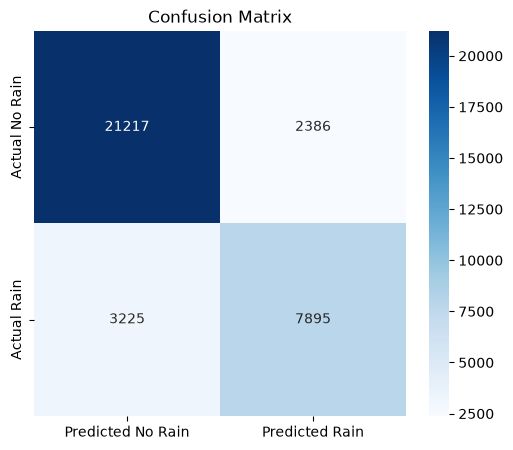

[[21217  2386]
 [ 3225  7895]]


In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

cm_matrix = pd.DataFrame(data=cm,
                          columns=['Predicted No Rain', 'Predicted Rain'],
                          index=['Actual No Rain', 'Actual Rain'])

plt.figure(figsize=(6,5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(cm)

#### Classification Report

Precision, recall, and F1-score give a more complete picture than accuracy alone — especially for imbalanced classes

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88     23603
           1       0.77      0.71      0.74     11120

    accuracy                           0.84     34723
   macro avg       0.82      0.80      0.81     34723
weighted avg       0.84      0.84      0.84     34723



#### Threshold Tuning

By default, the model predicts "rain" when the predicted probability is ≥ 0.5. But this threshold isn't sacred

In [38]:
from sklearn.preprocessing import binarize

# get the probability of rain (class 1) for each test row
y_pred_prob_rain = logreg.predict_proba(X_test)[:, 1]

# try different thresholds and see how accuracy and recall change
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_thresh = (y_pred_prob_rain >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_thresh)
    accuracy_t = accuracy_score(y_test, y_pred_thresh)
    recall_t = cm_t[1,1] / (cm_t[1,1] + cm_t[1,0])
    precision_t = cm_t[1,1] / (cm_t[1,1] + cm_t[0,1])
    print(f'Threshold={threshold} | Accuracy={accuracy_t:.4f} | Precision={precision_t:.4f} | Recall={recall_t:.4f}')

Threshold=0.2 | Accuracy=0.7981 | Precision=0.6291 | Recall=0.9007
Threshold=0.3 | Accuracy=0.8235 | Precision=0.6829 | Recall=0.8381
Threshold=0.4 | Accuracy=0.8367 | Precision=0.7300 | Recall=0.7779
Threshold=0.5 | Accuracy=0.8384 | Precision=0.7679 | Recall=0.7100
Threshold=0.6 | Accuracy=0.8331 | Precision=0.8036 | Recall=0.6336


Threshold tuning results

Lowering the threshold increases recall (catches more real rain days) but reduces precision (more false alarms) — and vice versa. At threshold 0.3, recall reaches 0.84 while precision drops to 0.68. At threshold 0.6, precision reaches 0.80 but recall falls to 0.63. The right threshold depends on the application — for rain prediction, a lower threshold is generally preferable since missing rain is more costly than a false alarm. The default 0.5 balances both, but 0.3-0.4 would be more practical for real-world use.

#### ROC-AUC

The ROC (Receiver Operating Characteristic) curve plots True Positive Rate (recall) against False Positive Rate at every possible threshold — giving a complete picture of the precision-recall trade-off in one graph. AUC (Area Under the Curve) summarizes this into a single number between 0 and 1: a perfect model scores 1.0, random guessing scores 0.5, and anything above 0.8 is generally considered good. Unlike accuracy, AUC is not affected by class imbalance, making it a more reliable overall measure of model quality.

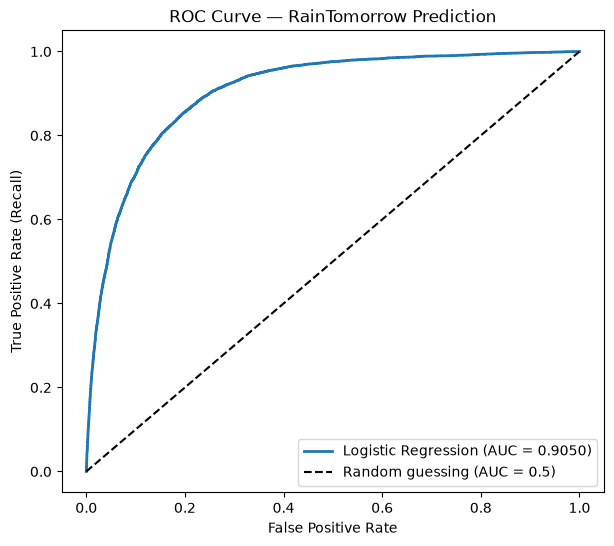

ROC AUC Score: 0.9050


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_rain)
roc_auc = roc_auc_score(y_test, y_pred_prob_rain)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — RainTomorrow Prediction')
plt.legend()
plt.show()

print('ROC AUC Score: {:.4f}'.format(roc_auc))

#### k-Fold Cross Validation

So far we've evaluated the model on one specific train/test split. But what if that split happened to be lucky (or unlucky)? k-Fold Cross Validation checks this by splitting the training data into 5 equal parts, training the model 5 times — each time using a different part as the validation set and the remaining 4 as training — then averaging the results. If the scores are consistent across all 5 folds, we can trust the model is genuinely stable and not just performing well on one particular split.

In [40]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')

print('Cross-validation scores for each fold:', cv_scores)
print('Mean CV accuracy: {:.4f}'.format(cv_scores.mean()))
print('Standard deviation: {:.4f}'.format(cv_scores.std()))

Cross-validation scores for each fold: [0.83509126 0.84037728 0.83540932 0.83868529 0.8369573 ]
Mean CV accuracy: 0.8373
Standard deviation: 0.0020


#### Hyperparameter Tuning with GridSearchCV

The model was trained with default settings — but these aren't necessarily optimal. GridSearchCV systematically tries different values of the regularization parameter C, evaluates each using 5-fold cross-validation, and identifies the best setting automatically. This ensures we're getting the best possible performance from Logistic Regression before drawing final conclusions.

In [41]:
from sklearn.model_selection import GridSearchCV

parameters = [{'C': [0.01, 0.1, 1, 10, 100]}]

grid_search = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', random_state=0),
    param_grid=parameters,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best C value        :', grid_search.best_params_)
print('Best CV accuracy    : {:.4f}'.format(grid_search.best_score_))
print('Test set accuracy   : {:.4f}'.format(grid_search.score(X_test, y_test)))

Best C value        : {'C': 0.1}
Best CV accuracy    : 0.8375
Test set accuracy   : 0.8383


GridSearchCV result

The optimal value found was C=0.1 (slightly stronger regularization than the default C=1), but the improvement over the default settings is negligible — test accuracy barely changed (0.8383 vs 0.8384). This confirms the model is already well-tuned and that the performance ceiling is determined by the feature set, not the hyperparameters.

In [42]:
import pickle 

pickle.dump(logreg, open("model.pkl", "wb"))

Results and Conclusion

Summary of results:

Metric	Value
Majority-class baseline	67.98%
Naive persistence baseline	84.55%
Logistic Regression accuracy	83.84%
ROC-AUC	0.9050
Cross-validation mean accuracy	83.73%
Best C (GridSearchCV)	0.1

Key findings:

The model comfortably beats the majority-class baseline (67.98%) by ~16 percentage points — it is definitely not a useless model.
The model scores just below the naive persistence baseline (84.55%) — revealing that rainfall-derived features alone can't provide information beyond what simple persistence already captures directly.
ROC-AUC of 0.905 shows the model's probability estimates are genuinely strong — it ranks rainy days above non-rainy days well across all possible thresholds, even if the default 0.5 threshold doesn't maximize accuracy.
Cross-validation (std=0.002) and GridSearchCV confirm the model is stable, consistent, and not overfitting.
The real performance ceiling here is the feature set, not the model or its settings — independent physical variables (temperature, humidity, wind, pressure) would be needed to meaningfully push past the persistence baseline.

What would improve this model:

Merge in daily temperature, humidity, wind speed and pressure data per state (NASA POWER API — free, no signup needed)
Try tree-based models (Random Forest, XGBoost) which handle non-linear monsoon transition effects better than Logistic Regression
Build separate per-state models instead of one pooled national model, since rainfall dynamics vary hugely between Kerala and Rajasthan